### Credits:

Materials in this notebook have been adapted from the following sources:

- © MIT 6.S191: Introduction to Deep Learning
http://introtodeeplearning.com

- Stanford CS class CS231n: Convolutional Neural Networks for Visual Recognition.
https://cs231n.github.io/


# Convolutional Neural Networks (CNNs)

Convolutional Neural Networks are very similar to ordinary Neural Networks from the previous chapter: they are made up of neurons that have learnable weights and biases. Each neuron receives some inputs, performs a dot product and optionally follows it with a non-linearity. The whole network still expresses a single differentiable score function: from the raw image pixels on one end to class scores at the other. And they still have an activation function (e.g. Softmax) on the last (fully-connected) layer and all the tips/tricks we developed for learning regular Neural Networks still apply.

So what changes? CNN architectures make the explicit assumption that the inputs are images, which allows us to encode certain properties into the architecture. These then make the forward function more efficient to implement and vastly reduce the amount of parameters in the network.


### Tensorflow 2.0

__What is Tensorflow?__

TensorFlow is a free and open-source software library for dataflow and differentiable programming across a range of tasks. It is a symbolic math library, and is also used for machine learning applications such as neural networks. It is used for both research and production at Google. 

TensorFlow was developed by the Google Brain team for internal Google use. It was released under the Apache License 2.0 on November 9, 2015. In Jan 2019, Google announced TensorFlow 2.0. It became officially available in Sep 2019.

## Part 1: MNIST Digit Classification

In the first portion of this lab, we will build and train a convolutional neural network (CNN) for classification of handwritten digits from the famous [MNIST](http://yann.lecun.com/exdb/mnist/) dataset. The MNIST dataset consists of 60,000 training images and 10,000 test images. Our classes are the digits 0-9.

First, let's download the course repository, install dependencies, and import the relevant packages we'll need for this lab.

In [ ]:
# Import Tensorflow 2.0
import tensorflow as tf
tf.config.set_visible_devices([], 'GPU') # Disable GPU for this notebook, as it is not needed and can cause issues with some installations
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt
import numpy as np
import random

%matplotlib inline

## MNIST dataset 

Let's download and load the dataset and display a few random samples from it:

In [2]:
mnist = tf.keras.datasets.mnist # The MNIST dataset comes as part of the Keras library
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = (np.expand_dims(train_images, axis=-1)/255.).astype(np.float32)
train_labels = (train_labels).astype(np.int64)
test_images = (np.expand_dims(test_images, axis=-1)/255.).astype(np.float32)
test_labels = (test_labels).astype(np.int64)

Our training set is made up of 28x28 grayscale images of handwritten digits. 

The initial dimensionality of dataset is `(num_of_images, height, width)`. For the training said that is 60000 x 28 x 28 and for the test set 10000 x 28 x 28. However, the neural network expects a fourth dimension, which is the number of channels. The statement `np.expand_dims` is used to add that extra dimenension. Here the images are grayscale so the value of the fourth dimesion is 1, so the new dimensionality becomes `(num_of_images, height, width, 1)`. If we had color images, the value would be 3 (for R-G-B). For other types of data with more channels, that value could be any integer.

Let's visualize what some of these images and their corresponding training labels look like.

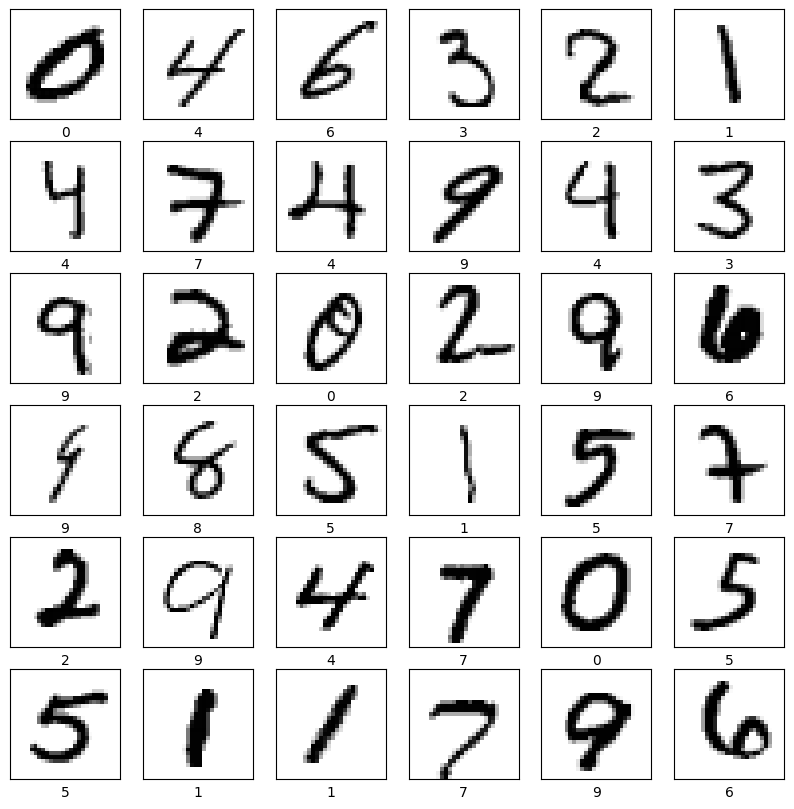

In [3]:
plt.figure(figsize=(10,10))
random_inds = np.random.choice(60000,36)
for i in range(36):
    plt.subplot(6,6,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    image_ind = random_inds[i]
    plt.imshow(np.squeeze(train_images[image_ind]), cmap=plt.cm.binary)
    plt.xlabel(train_labels[image_ind])

## Neural Network for Handwritten Digit Classification

We'll first build a simple neural network consisting of two fully connected layers and apply this to the digit classification task. Our network will ultimately output a probability distribution over the 10 digit classes (0-9). This first architecture we will be building is depicted below:

![alt_text](https://raw.githubusercontent.com/aamini/introtodeeplearning/master/lab2/img/mnist_2layers_arch.png "CNN Architecture for MNIST Classification")


### Fully connected neural network architecture
To define the architecture of this first fully connected neural network, we'll once again use the Keras API and define the model using the [`Sequential`](https://www.tensorflow.org/api_docs/python/tf/keras/models/Sequential) class. Note how we first use a [`Flatten`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Flatten) layer, which flattens the input so that it can be fed into the model. 

In this next block, you'll define the fully connected layers of this simple work.

In [4]:
def build_fc_model():
  fc_model = tf.keras.Sequential([
      # First define a Flatten layer
      layers.Flatten(),

      # Define the activation function for the first fully connected (Dense) layer.
      layers.Dense(128, activation='relu'),

      # Define the second Dense layer to output the classification probabilities
      layers.Dense(10, activation='softmax') 
  ])
  return fc_model

model = build_fc_model()

As we progress through this next portion, you may find that you'll want to make changes to the architecture defined above. **Note that in order to update the model later on, you'll need to re-run the above cell to re-initialize the model. **

Let's take a step back and think about the network we've just created. The first layer in this network, `tf.keras.layers.Flatten`, transforms the format of the images from a 2d-array (28 x 28 pixels), to a 1d-array of 28 * 28 = 784 pixels. You can think of this layer as unstacking rows of pixels in the image and lining them up. There are no learned parameters in this layer; it only reformats the data.

After the pixels are flattened, the network consists of a sequence of two `tf.keras.layers.Dense` layers. These are fully-connected neural layers. The first `Dense` layer has 128 nodes (or neurons). The second (and last) layer (which you've defined!) should return an array of probability scores that sum to 1. Each node contains a score that indicates the probability that the current image belongs to one of the handwritten digit classes.

That defines our fully connected model! 



### Compile the model

Before training the model, we need to define a few more settings. These are added during the model's [`compile`](https://www.tensorflow.org/api_docs/python/tf/keras/models/Sequential#compile) step:

* *Loss function* — This defines how we measure how accurate the model is during training. As was covered in lecture, during training we want to minimize this function, which will "steer" the model in the right direction. We will use Crossentropy loss.
* *Optimizer* — This defines how the model is updated based on the data it sees and its loss function. See [documentation](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers).
* *Metrics* — Here we can define metrics used to monitor the training and testing steps. In this example, we'll look at the *accuracy*, the fraction of the images that are correctly classified. See [documentation](https://www.tensorflow.org/api_docs/python/tf/keras/metrics).

We'll start out by using a stochastic gradient descent (SGD) optimizer initialized with a learning rate of 0.1. Since we are performing a categorical classification task, we'll want to use the Crossentropy loss.

**Note**:
If you have a multi-class (more than two classes) classification problem, you should use `SparseCategoricalCrossentropy` loss or `CategoricalCrossentropy` loss. 
`SparseCategoricalCrossentropy` computes the crossentropy loss between the labels and predictions. Use this crossentropy loss function when there are two or more label classes and the labels are provided as integers. If you want to provide labels using _one-hot_ representation, use `CategoricalCrossentropy` loss. With either version of categorical cross entropy losses, we expect the predictions to be an array of probabilities (i.e., they should sum to 1). Also the activation function of the output layer should be `softmax`.


See [Tensorflow documentation](https://www.tensorflow.org/api_docs/python/tf/keras/losses/SparseCategoricalCrossentropy) for more details.

If you have a binary classification problem (two classes), then use either categorical cross entropy with two neurons in the output layer or `BinaryCrossentropy` loss with a single neuron in the output layer. With `BinaryCrossentropy` loss, we expect predictions to be a single floating point value per output representing the probability of the the positive class (class "1"). Also the activation function of the output layer should be `sigmoid` instead of `softmax`.
See [Tensorflow documentation](https://www.tensorflow.org/api_docs/python/tf/keras/losses/BinaryCrossentropy) for more details.

You'll want to experiment with both the choice of optimizer and learning rate and evaluate how these affect the accuracy of the trained model. 

In [5]:
'''TODO: Experiment with different optimizers and learning rates. How do these affect
    the accuracy of the trained model? Which optimizers and/or learning rates yield
    the best performance?'''
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=1e-1), 
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

Note: the parameter `from_logits` specifies if the loss should be calculated based on the output of the softmax function (i.e. in the range [0, 1]) or based on the output of a logit function (i.e. direct neuron output without any activation function in the range [-inf, +inf]). In this case we are using a softmax activation function in the output layer, so the `from_logits` parameter is set to `False`.

### Train the model

We're now ready to train our model, which will involve feeding the training data (`train_images` and `train_labels`) into the model, and then asking it to learn the associations between images and labels. We'll also need to define the batch size and the number of epochs, or iterations over the MNIST dataset, to use during training. 

In [6]:
# Define the batch size and the number of epochs to use during training
BATCH_SIZE = 64
EPOCHS = 20

# Fit the model to the training data
history = model.fit(train_images, train_labels, batch_size=BATCH_SIZE, epochs=EPOCHS, 
                    validation_data=(test_images, test_labels))

Epoch 1/20


I0000 00:00:1777440372.630620  636126 service.cc:152] XLA service 0x7dddcc00d9a0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777440372.630691  636126 service.cc:160]   StreamExecutor device (0): Host, Default Version
2026-04-29 00:26:12.647103: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


 72/938 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5639 - loss: 1.4794

I0000 00:00:1777440372.870867  636126 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8373 - loss: 0.5857 - val_accuracy: 0.9403 - val_loss: 0.2111
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9432 - loss: 0.2006 - val_accuracy: 0.9548 - val_loss: 0.1589
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9575 - loss: 0.1520 - val_accuracy: 0.9618 - val_loss: 0.1307
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9670 - loss: 0.1178 - val_accuracy: 0.9668 - val_loss: 0.1114
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9720 - loss: 0.0993 - val_accuracy: 0.9709 - val_loss: 0.1027
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9755 - loss: 0.0890 - val_accuracy: 0.9702 - val_loss: 0.0984
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9794 - loss: 0.0749 - val_accuracy: 0.9719 - val_loss: 0.0900
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9810 - loss: 0.0702 - val_accuracy: 0.9755 - val_

### Evaluate accuracy on the test dataset

Now that we've trained the model, we can ask it to make predictions about a test set that it hasn't seen before. In this example, the `test_images` array comprises our test dataset. To evaluate accuracy, we can check to see if the model's predictions match the labels from the `test_labels` array. 

Use the [`evaluate`](https://www.tensorflow.org/api_docs/python/tf/keras/models/Sequential#evaluate) method to evaluate the model on the test dataset!

In [7]:
#Use the evaluate method to test the model!
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2) 

print('Test accuracy:', test_acc)

313/313 - 1s - 2ms/step - accuracy: 0.9796 - loss: 0.0653
Test accuracy: 0.9796000123023987


We can also visulalize the training and test error for each epoch that was accumulated in `history` when we fit the model.

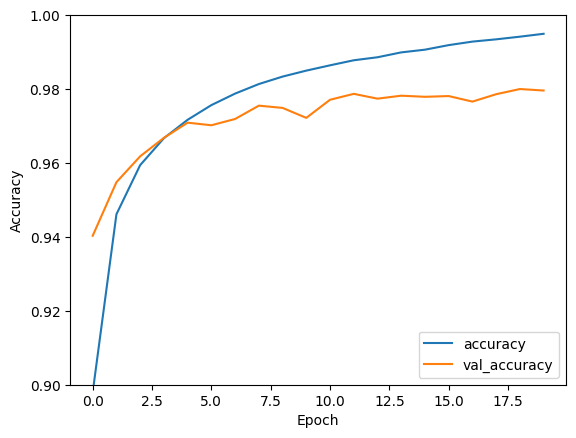

In [8]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.9, 1])
plt.legend(loc='lower right')

For each instance classified there should be `#classes` floating point values per feature for `y_pred` and a single floating point value per feature for `y_true`.

In [9]:
# Get a random test image
index = np.random.choice(test_images.shape[0])
test_image = test_images[index]

# Get the true label of the image
true_label = test_labels[index]

# Reshape the image to (1, 28, 28, 1) to match the input shape of the model
# The first dimension is the number of images, but we only have 1 image here.
test_image = np.reshape(test_image, (1, 28, 28, 1))

# Get a prediction from the model
prediction_probabilities = model.predict(test_image)

print(prediction_probabilities)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
[[1.2620916e-07 9.9826497e-01 1.8483555e-05 2.4841986e-06 4.0274408e-06
  1.1524542e-07 1.3502805e-07 1.0685935e-03 6.4057822e-04 4.7422026e-07]]


In [10]:
# Get the label with the highest confidence and use that as the prediction
y_pred = np.argmax(prediction_probabilities, axis=1)
print('Expected label: ', true_label)
print('Predicted label: ', y_pred[0])

Expected label:  1
Predicted label:  1


What is the highest accuracy you can achieve with this first fully connected model? Since the handwritten digit classification task is pretty straightforward, you may be wondering how we can do better...

![Deeper...](https://i.kym-cdn.com/photos/images/newsfeed/000/534/153/f87.jpg)

## Convolutional Neural Network (CNN) for handwritten digit classification

As we saw in lecture, convolutional neural networks (CNNs) are particularly well-suited for a variety of tasks in computer vision, and have achieved near-perfect accuracies on the MNIST dataset. We will now build a CNN composed of two convolutional layers and pooling layers, followed by two fully connected layers, and ultimately output a probability distribution over the 10 digit classes (0-9). The CNN we will be building is depicted below:

![alt_text](https://raw.githubusercontent.com/aamini/introtodeeplearning/master/lab2/img/convnet_fig.png "CNN Architecture for MNIST Classification")

### Define the CNN model

We'll use the same training and test datasets as before, and proceed similarly as our fully connected network to define and train our new CNN model. To do this we will explore two layers we have not encountered before: you can use  [`keras.layers.Conv2D` ](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D) to define convolutional layers and [`keras.layers.MaxPool2D`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/MaxPool2D) to define the pooling layers. Use the parameters shown in the network architecture above to define these layers and build the CNN model.

Our network architecture looks as follows:

- INPUT [28x28] will hold the raw pixel values of the image, in this case an image of width 28, height 28, and with single color channel (grayscale).
- CONV layer will compute the output of neurons that are connected to local regions in the input, each computing a dot product between their weights and a small region they are connected to in the input volume. This may result in volume such as [26x26x24] if we decided to use 24 filters of size [3x3].
- RELU layer will apply an elementwise activation function, such as the max(0,x) thresholding at zero. This leaves the size of the volume unchanged ([26x26x24]).
- POOL layer will perform a downsampling operation along the spatial dimensions (width, height), resulting in volume such as [13x13x24].
- CONV layer will compute the output of neurons that are connected to the output of the previous max-pooling layer, each computing a dot product between their weights and a small region they are connected to in the input volume. This may result in volume such as [11x11x36] if we decided to use 36 filters of size [3x3].
- RELU layer will apply an elementwise activation function, such as the max(0,x) thresholding at zero. This leaves the size of the volume unchanged ([11x11x36]).
- POOL layer will perform a downsampling operation along the spatial dimensions (width, height), resulting in volume such as [5x5x36].
- FL (i.e. flatten) layer will flatten the [5x5x36] into a vector of dimension 900.
- FC (i.e. fully-connected) layer reduce the previous 900 units to 128.
- RELU layer will apply an elementwise activation function, such as the max(0,x) thresholding at zero. This leaves the size of the vector unchanged ([128]).
- DROPOUT layer will randomly set 20% of the neurons to zero. Dropout can help prevent overfitting the training set. This leaves the size of the vector unchanged ([128]).
- FC (i.e. fully-connected) layer will compute the class scores, resulting in volume of size [1x1x10], where each of the 10 numbers correspond to a class score. As with ordinary Neural Networks and as the name implies, each neuron in this layer will be connected to all the numbers in the previous volume.
- The softmax activation function will convert the output score to a probability [0, 1].


In this way, CNNs transform the original image layer by layer from the original pixel values to the final class scores. Note that some layers contain parameters and other don’t. In particular, the CONV/FC layers perform transformations that are a function of not only the activations in the input volume, but also of the parameters (the weights and biases of the neurons). On the other hand, the RELU/POOL layers will implement a fixed function. The parameters in the CONV/FC layers will be trained with gradient descent so that the class scores that the CNN computes are consistent with the labels in the training set for each image.

In [11]:
def build_cnn_model():
    cnn_model = tf.keras.models.Sequential()

    # Define the first convolutional layer
    cnn_model.add(layers.Conv2D(filters=25, kernel_size=(3,3), activation='relu', input_shape=(28, 28, 1), name='conv2d_1'))

    # Define the first max pooling layer
    cnn_model.add(layers.MaxPool2D(pool_size=(2,2), name='maxpool2d_1'))

    # Define the second convolutional layer
    cnn_model.add(layers.Conv2D(filters=36, kernel_size=(3,3), activation='relu', name='conv2d_2'))

    # Define the second max pooling layer
    cnn_model.add(layers.MaxPool2D(pool_size=(2,2), name='maxpool2d_2'))

    # Flatten the volume into a vector
    cnn_model.add(layers.Flatten(name='flatten_1'))
    
    # A hidden fully connected layer
    cnn_model.add(layers.Dense(128, activation='relu', name='dense_1'))

    # Add dropout layer
    cnn_model.add(layers.Dropout(0.3, name='dropout_1'))

    # Define the last Dense layer to output the classification probabilities. 
    # Pay attention to the activation needed for a probability output
    cnn_model.add(layers.Dense(10, activation='softmax', name='output'))

    return cnn_model
  
cnn_model = build_cnn_model()

# Print the summary of the layers in the model.
print(cnn_model.summary())

/home/vangelis/miniconda3/envs/ml/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 25)     │           250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 13, 13, 25)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 36)     │         8,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 5, 5, 36)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 900)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       115,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,004 (488.30 KB)

 Trainable params: 125,004 (488.30 KB)

 Non-trainable params: 0 (0.00 B)

None


### Train and test the CNN model

Now, as before, we can define the loss function, optimizer, and metrics through the `compile` method. Compile the CNN model with an optimizer and learning rate of choice:

In [12]:
#Define the compile operation with your optimizer and learning rate of choice
cnn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

As was the case with the fully connected model, we can train our CNN using the `fit` method via the Keras API.

In [13]:
# Define the batch size and the number of epochs to use during training
BATCH_SIZE = 64
EPOCHS = 20

# Use model.fit to train the CNN model, with the same batch_size and number of epochs previously used.
history = cnn_model.fit(train_images, train_labels, batch_size=BATCH_SIZE, epochs=EPOCHS,
                        validation_data=(test_images, test_labels))

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 63s 65ms/step - accuracy: 0.8573 - loss: 0.4587 - val_accuracy: 0.9812 - val_loss: 0.0537
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 57s 60ms/step - accuracy: 0.9785 - loss: 0.0707 - val_accuracy: 0.9862 - val_loss: 0.0437
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 62s 67ms/step - accuracy: 0.9852 - loss: 0.0508 - val_accuracy: 0.9891 - val_loss: 0.0339
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 54s 58ms/step - accuracy: 0.9867 - loss: 0.0408 - val_accuracy: 0.9874 - val_loss: 0.0361
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 48s 51ms/step - accuracy: 0.9890 - loss: 0.0356 - val_accuracy: 0.9904 - val_loss: 0.0285
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 49s 52ms/step - accuracy: 0.9907 - loss: 0.0279 - val_accuracy: 0.9914 - val_loss: 0.0261
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 56s 60ms/step - accuracy: 0.9931 - loss: 0.0217 - val_accuracy: 0.9901 - val_loss: 0.0293
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 64s 68ms/step - accuracy: 0.9940 - loss: 0.0197 - 

Let's plot the training history.

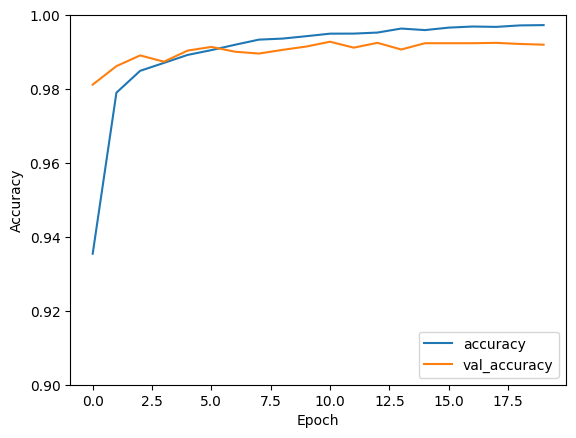

In [14]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.9, 1])
plt.legend(loc='lower right')

Great! Now that we've trained the model, let's evaluate it on the test dataset using the [`evaluate`](https://www.tensorflow.org/api_docs/python/tf/keras/models/Sequential#evaluate) method:

In [15]:
# Use the evaluate method to test the model!
test_loss, test_acc = cnn_model.evaluate(test_images, test_labels)

print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9882 - loss: 0.0400
Test accuracy: 0.9919999837875366


What is the highest accuracy you're able to achieve using the CNN model, and how does the accuracy of the CNN model compare to the accuracy of the simple fully connected network? What optimizers and learning rates seem to be optimal for training the CNN model? 

### Make predictions with the CNN model

With the model trained, we can use it to make predictions about some images. The [`predict`](https://www.tensorflow.org/api_docs/python/tf/keras/models/Sequential#predict) function call generates the output predictions given a set of input samples.


In [16]:
predictions = cnn_model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


With this function call, the model has predicted the label for each image in the testing set. Let's take a look at the prediction for the first image in the test dataset:

In [17]:
predictions[0]

array([1.4133962e-14, 8.7067070e-10, 1.8310585e-12, 8.8888014e-10,
       2.3216558e-09, 1.9734248e-13, 2.0269621e-17, 1.0000000e+00,
       1.4934741e-13, 1.8562222e-08], dtype=float32)

As you can see, a prediction is an array of 10 numbers. Recall that the output of our model is a probability distribution over the 10 digit classes. Thus, these numbers describe the model's "confidence" that the image corresponds to each of the 10 different digits. 

Let's look at the digit that has the highest confidence for the first image in the test dataset:

In [18]:
# Identify the digit with the highest confidence prediction for the first image in the test dataset.
prediction = np.argmax(predictions[0]) 

print(prediction)

7


So, the model is most confident that this image is a "7". We can check the test label (remember, this is the true identity of the digit) to see if this prediction is correct:

Label of this digit is: 7


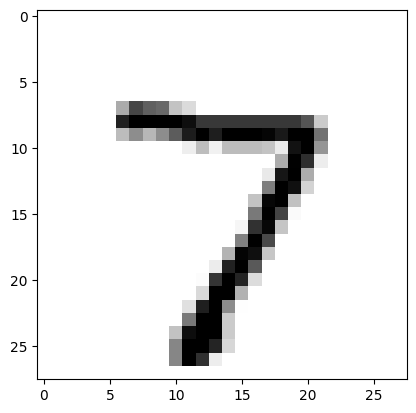

In [19]:
print("Label of this digit is:", test_labels[0])
plt.imshow(test_images[0,:,:,0], cmap=plt.cm.binary)

### Layers

The most common form of a CNNs architecture stacks a few CONV-RELU layers, follows them with POOL layers, and repeats this pattern until the image has been merged spatially to a small size. At some point, it is common to transition to fully-connected layers. The last fully-connected layer holds the output, such as the class scores. In other words, the most common CNNs architecture follow the pattern:

`INPUT -> [[CONV -> RELU]*N -> POOL?]*M -> [FC -> RELU]*K -> FC`

where the `*` indicates repetition, and the `POOL?` indicates an optional pooling layer. Moreover, `N >= 0` (and usually `N <= 3`), `M >= 0`, `K >= 0` (and usually `K < 3`). For example, here are some common CNN architectures you may see that follow this pattern:

- `INPUT -> FC`, implements a linear classifier. Here `N = M = K = 0`.
- `INPUT -> CONV -> RELU -> FC`
- `INPUT -> [CONV -> RELU -> POOL]*2 -> FC -> RELU -> FC`. Here we see that there is a single CONV layer between every POOL layer.
- `INPUT -> [CONV -> RELU -> CONV -> RELU -> POOL]*3 -> [FC -> RELU]*2 -> FC` Here we see two CONV layers stacked before every POOL layer. This is generally a good idea for larger and deeper networks, because multiple stacked CONV layers can develop more complex features of the input volume before the destructive pooling operation.

If you notice a substantial gap between the training and test accuracy, this is an indication of overfitting. Some common ways to reduce overfitting is to use more training data, reduce the capacity of the network, or add regularization such as weight decay or **dropout**.

## Feature Extraction and Visualization from CNN layers

Feature extraction and visualization in neural networks, particularly Convolutional Neural Networks (CNNs), is an interesting topic that provides insights into what the network "sees" and "learns". Let's delve into it.

### Feature Extraction in Neural Networks:

1. **What is Feature Extraction?**
   Feature extraction involves accessing the intermediate outputs of neural network layers. These outputs, known as "feature maps" in CNNs, represent the learned features from the input data at different levels of abstraction. 

2. **Why is it Important?**
   Understanding what features a neural network extracts can help in diagnosing model behaviors, improving model architectures, and gaining insights into the network's internal workings. It helps determine whether the network is learning meaningful or irrelevant patterns.

### Visualization of Features:

1. **Visualizing Initial Layers**: 
   In CNNs, initial layers usually learn low-level features like edges, textures, and colors. Visualizing feature maps from these layers might show patterns resembling various edge orientations or color contrasts.

2. **Visualizing Deeper Layers**: 
   As we move deeper into the network, the layers start learning higher-level features, which capture more abstract representations and combinations of the earlier features. For instance, in a face recognition task, while the initial layers might capture edges and textures, deeper layers might capture patterns corresponding to eyes, noses, or even whole faces.

3. **Visualization Techniques**:
   - **Feature Maps**: Displaying the output of specific layers given a particular input. This is particularly common with CNNs where each channel of a feature map can be visualized as an image.
   - **Filter Visualization**: Instead of visualizing the feature maps, we can visualize the filters/kernels themselves, especially in the initial layers. This can show what kind of patterns a filter is designed to detect.
   - **Activation Maximization**: This technique aims to find the input that maximizes the activation of particular neurons or layers. It helps to see what kind of input patterns a neuron is most responsive to.
   - **Embedding Visualization**: For fully connected layers, especially in deep networks, we can use dimensionality reduction techniques (like t-SNE or PCA) to visualize high-dimensional features in 2D or 3D space.
   - **Heatmaps**: These show which parts of an input image contribute most to a neural network's decision. Techniques like Grad-CAM fall under this category.

### Process of Feature Extraction and Visualization:

1. **Select Layer(s) of Interest**: Decide which layer(s) you want to investigate. For beginners, starting with the first few layers can be intuitive since the features are more recognizable.

2. **Build a Feature Extractor Model**: Using tools like TensorFlow or Keras, you can modify your trained model to output the feature maps of the desired layers.

3. **Provide an Input**: Pass an input (e.g., an image) through the feature extractor model. This will give you the feature maps for that input.

4. **Visualize the Outputs**: Depending on the layer type and depth, you can use various visualization techniques. For CNNs, you can treat feature maps as images and display them.

5. **Interpret the Visualizations**: Examine the visualizations to gain insights. For instance, if you see all feature maps from a layer being almost blank for multiple inputs, it might indicate that the layer isn't learning meaningful patterns.

In summary, feature extraction and visualization in neural networks are powerful techniques to understand and interpret the model's behavior. They offer a peek into the black box of neural networks, helping researchers and practitioners make more informed decisions about model design and deployment.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step


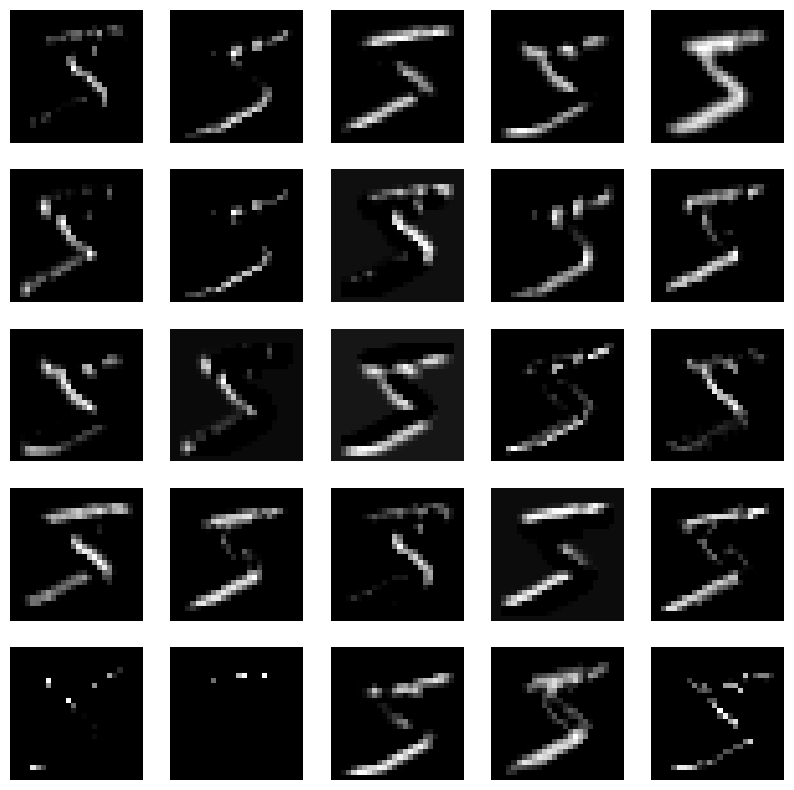

In [20]:
def visualize_layer(model, layer_name, input_image):
    ''' Visualizes the features learned by a specific layer given an input image '''
    # Create a feature extractor model
    feature_extractor = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=model.get_layer(layer_name).output
    )
    
    # Preprocess the image
    input_image = np.expand_dims(input_image, axis=0)  # make it (1, 28, 28, 1) shape

    # Get the feature maps for the given input image
    features = feature_extractor.predict(input_image)
    
    # Visualize the feature maps
    num_filters = features.shape[-1]
    size = int(np.ceil(np.sqrt(num_filters)))  # Calculate grid size for displaying features

    fig, axarr = plt.subplots(size, size, figsize=(10, 10))
    
    for idx in range(num_filters):
        ax = axarr[idx // size, idx % size]
        ax.imshow(features[0, :, :, idx], cmap='gray')
        ax.axis('off')
    plt.show()


(train_images, train_labels), _ = tf.keras.datasets.mnist.load_data()
sample_image = train_images[0] / 255.0
sample_image = np.expand_dims(sample_image, axis=-1)  # Convert it to (28, 28, 1)

# Visualize the features learned by the second convolutional layer
visualize_layer(cnn_model, 'conv2d_1', sample_image)

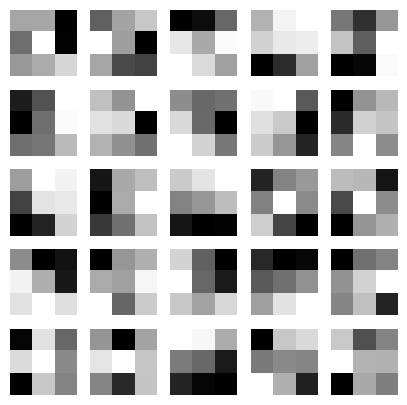

In [21]:
def visualize_filters(model, layer_name):
    ''' Visualizes the filters of a specific convolutional layer '''
    
    # Extract the weights from the desired layer
    layer_weights = model.get_layer(layer_name).get_weights()[0]
    
    # Normalize the weights for visualization
    layer_weights_min, layer_weights_max = layer_weights.min(), layer_weights.max()
    layer_weights = (layer_weights - layer_weights_min) / (layer_weights_max - layer_weights_min)
    
    # Get the number of filters in the layer
    num_filters = layer_weights.shape[-1]

    # Calculate grid size for displaying filters
    size = int(np.ceil(np.sqrt(num_filters)))

    # Plot the filters
    fig, axarr = plt.subplots(size, size, figsize=(5, 5))

    for idx in range(num_filters):
        ax = axarr[idx // size, idx % size]
        ax.imshow(layer_weights[:, :, 0, idx], cmap='gray')
        ax.axis('off')
    
    plt.show()

# Visualize the filters of the first convolutional layer (change the layer_name accordingly)
visualize_filters(cnn_model, 'conv2d_1')

## Conclusion
In this part of the lab, you had the chance to play with different MNIST classifiers with different architectures (fully-connected layers only, CNN), and experiment with how different hyperparameters affect accuracy (learning rate, etc.).

A similar example with using the CIFAR10 dataset for color image classification:
https://www.tensorflow.org/tutorials/images/cnn